<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/Modulo6_Sesion1_Anomalias_Clustering_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="border-left: 8px solid #9B004C; padding: 12px 18px; background: #F8F9FA;">
  <h1 style="color:#9B004C; margin:0;">Módulo 6 · Sesión 1</h1>
  <h2 style="color:#404040; margin:6px 0;">Detección de anomalías y segmentación de activos</h2>
  <p style="color:#404040; margin:0;"><b>Versión alumno</b> · Ingenium</p>
</div>

## Propósito

Aplicar un flujo profesional de detección de anomalías y clustering sobre datos SCADA reales. Al finalizar podrás:

- construir un baseline normal sin fuga temporal;
- comparar Isolation Forest y Local Outlier Factor;
- evaluar alertas contra una ventana de evento;
- crear perfiles mensuales y segmentar activos mediante K-Means.


> **Fuente profesional:** Gück, Roelofs y Faulstich, *Wind Turbine SCADA Data For Early Fault Detection*, versión 6. Datos SCADA reales de aerogeneradores industriales, publicados por Fraunhofer IEE. DOI: [10.5281/zenodo.15846963](https://doi.org/10.5281/zenodo.15846963).

El archivo completo pesa aproximadamente 5.5 GB. El notebook utiliza solicitudes HTTP parciales para extraer únicamente los CSV necesarios desde el ZIP oficial; no descarga el conjunto completo ni genera datos sintéticos.

## 1. Preparación del entorno

In [1]:
!pip -q install remotezip

from io import BytesIO
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from remotezip import RemoteZip
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

## 2. Selección profesional de datos y variables

Trabajaremos con el parque A porque conserva descripciones físicas de las señales. Se utilizarán variables `Avg`, recomendadas por la documentación de la versión 6. Los eventos elegidos cubren los cinco activos del parque sin mezclar archivos anteriores del curso.

In [2]:
ZENODO_ZIP = "https://zenodo.org/records/15846963/files/CARE_To_Compare.zip?download=1"
ROOT = "CARE_To_Compare/Wind Farm A"

EVENT_IDS = [0, 3, 13, 25, 38]
SIGNALS = [
    "sensor_0_avg", "wind_speed_3_avg", "power_30_avg",
    "sensor_11_avg", "sensor_12_avg", "sensor_13_avg",
    "sensor_14_avg", "sensor_18_avg", "sensor_41_avg", "sensor_52_avg",
]
BASE_COLS = ["time_stamp", "asset_id", "id", "train_test", "status_type_id"]
USECOLS = BASE_COLS + SIGNALS

## 3. Extracción selectiva desde Zenodo

La celda siguiente lee solo cinco CSV internos. La primera ejecución puede tardar porque los miembros se extraen directamente del ZIP remoto.

In [3]:
def read_csv_member(archive, member, usecols=None):
    raw = archive.read(member)
    return pd.read_csv(BytesIO(raw), sep=";", usecols=usecols)

with RemoteZip(ZENODO_ZIP) as archive:
    event_info = read_csv_member(archive, f"{ROOT}/event_info.csv")
    feature_info = read_csv_member(archive, f"{ROOT}/feature_description.csv")
    frames = {
        event_id: read_csv_member(
            archive,
            f"{ROOT}/datasets/{event_id}.csv",
            usecols=USECOLS,
        )
        for event_id in EVENT_IDS
    }

for event_id, frame in frames.items():
    frame["time_stamp"] = pd.to_datetime(frame["time_stamp"], errors="coerce")
    frame["event_id"] = event_id
    frames[event_id] = frame.sort_values("time_stamp").drop_duplicates("time_stamp")

event_info.query("event_id in @EVENT_IDS").sort_values("event_id")

,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
4,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure
15,10,3,normal,2023-04-27 03:00:00,52185,2023-05-18 01:10:00,55198,NaN
13,21,13,normal,2023-05-03 13:20:00,50859,2023-05-24 10:20:00,53865,NaN
11,11,25,normal,2023-05-23 06:50:00,52289,2023-06-05 02:30:00,54135,NaN
17,13,38,normal,2023-07-01 15:40:00,52723,2023-07-15 07:40:00,54546,NaN


## 4. Auditoría de calidad y trazabilidad

In [4]:
quality = []
for event_id, frame in frames.items():
    quality.append({
        "event_id": event_id,
        "asset_id": frame["asset_id"].iloc[0],
        "rows": len(frame),
        "duplicates": frame["time_stamp"].duplicated().sum(),
        "missing_pct": frame[SIGNALS].isna().mean().mean() * 100,
        "start": frame["time_stamp"].min(),
        "end": frame["time_stamp"].max(),
    })

quality = pd.DataFrame(quality)
quality

,event_id,asset_id,rows,duplicates,missing_pct,start,end
0,0,0,54986,0,0.000182,2022-08-04 06:10:00,2023-08-24 06:10:00
1,3,10,55487,0,0.000360,2022-04-27 03:00:00,2023-05-20 01:10:00
2,13,21,54010,0,0.000000,2022-04-30 13:20:00,2023-05-25 10:20:00
3,25,11,54712,0,0.000000,2022-05-23 06:50:00,2023-06-09 02:30:00
4,38,13,54835,0,0.000000,2022-06-28 15:40:00,2023-07-17 07:40:00


### Ejercicio 1 — Revisar la calidad

1. Calcula el porcentaje de valores faltantes por señal para el evento 0.
2. Identifica señales constantes o con variabilidad casi nula.
3. Explica por qué una señal constante no ayuda a Isolation Forest.

### Solución Ejercicio 1

In [15]:
# 1. Calcula el porcentaje de valores faltantes por señal para el evento 0.
missing_percentages = event0[SIGNALS].isna().mean() * 100
print("Porcentaje de valores faltantes por señal (Evento 0):")
print(missing_percentages[missing_percentages > 0])
event0_q= frames[0][SIGNALS]
missbysignal= event0_q.isna().mean().mul(100).sort_values(ascending=True)
print(missbysignal)
stdbysignal= event0_q.std().sort_values(ascending=True)
print(stdbysignal)
qualitybysignal =pd.DataFrame(
    {
      "missing_pct": missbysignal,
      "std": stdbysignal
    }
)

Porcentaje de valores faltantes por señal (Evento 0):
sensor_14_avg    0.001819
dtype: float64
sensor_0_avg        0.000000
wind_speed_3_avg    0.000000
power_30_avg        0.000000
sensor_11_avg       0.000000
sensor_12_avg       0.000000
sensor_13_avg       0.000000
sensor_18_avg       0.000000
sensor_41_avg       0.000000
sensor_52_avg       0.000000
sensor_14_avg       0.001819
dtype: float64
power_30_avg          0.351920
wind_speed_3_avg      3.985269
sensor_52_avg         5.616096
sensor_0_avg          5.747968
sensor_12_avg         6.292273
sensor_41_avg         8.033555
sensor_11_avg         9.145329
sensor_14_avg        15.040444
sensor_13_avg        15.316419
sensor_18_avg       621.219482
dtype: float64


In [13]:
# 2. Identifica señales constantes o con variabilidad casi nula.
# Calculamos la desviación estándar de cada señal.
signal_std = event0[SIGNALS].std()

# Definimos un umbral bajo para considerar una señal casi nula.
# Un valor muy pequeño, cercano a cero, indica poca o ninguna variabilidad.
CONSTANT_THRESHOLD = 1e-6
constant_signals = signal_std[signal_std < CONSTANT_THRESHOLD]

print("\nSeñales constantes o con variabilidad casi nula (Evento 0):")
if not constant_signals.empty:
    print(constant_signals)
else:
    print("No se encontraron señales constantes o con variabilidad casi nula.")


Señales constantes o con variabilidad casi nula (Evento 0):
No se encontraron señales constantes o con variabilidad casi nula.


### 3. Explica por qué una señal constante no ayuda a Isolation Forest.

Isolation Forest funciona aislando las anomalías, que son puntos de datos que están 'lejos' de la mayoría de los datos, requiriendo menos particiones aleatorias para ser aislados. Este algoritmo construye árboles de decisión donde las divisiones se hacen sobre rangos de valores de las características.

Si una señal (o característica) es **constante** o tiene una **variabilidad casi nula**, significa que todos (o casi todos) los puntos de datos tienen el mismo valor para esa señal. En este escenario:

*   **No aporta información discriminatoria:** Una característica constante no puede ser utilizada para realizar particiones efectivas, ya que no hay variación para separar los puntos de datos. Todos los puntos caerían en la misma rama del árbol en esa dimensión.
*   **Reduce la dimensionalidad efectiva:** De hecho, es como si esa dimensión no existiera para el algoritmo, ya que no contribuye a la diferenciación entre puntos normales y anómalos.
*   **Puede generar problemas numéricos:** Si se usa un escalador (como `StandardScaler`) que normaliza dividiendo por la desviación estándar, una desviación estándar de cero (o muy cercana a cero) causaría una división por cero o produciría valores `NaN` o `infinitos`, lo que rompería el pipeline.

En resumen, Isolation Forest se basa en la variabilidad de las características para construir sus árboles y aislar las anomalías. Una señal constante no ofrece esta variabilidad, por lo que no contribuye al proceso de detección de anomalías y debería ser eliminada o tratada antes de entrenar el modelo.

## 5. Baseline normal y separación temporal

El evento 0 corresponde a una falla de rodamiento del generador. El modelo se ajustará únicamente con filas `train` y estados 0 o 2, considerados operación normal o idling por la documentación.

In [5]:
event0 = frames[0].copy()
meta0 = event_info.loc[event_info["event_id"].eq(0)].iloc[0]

train_mask = event0["train_test"].eq("train") & event0["status_type_id"].isin([0, 2])
score_mask = event0["train_test"].eq("prediction")

X_train = event0.loc[train_mask, SIGNALS]
X_prediction = event0.loc[score_mask, SIGNALS]

print("Entrenamiento:", X_train.shape)
print("Predicción:", X_prediction.shape)
print("Evento:", meta0["event_description"])
print("Ventana:", meta0["event_start"], "→", meta0["event_end"])

Entrenamiento: (47252, 10)
Predicción: (2838, 10)
Evento: Generator bearing failure
Ventana: 2023-08-06 06:10:00 → 2023-08-20 06:10:00


## 6. Isolation Forest con pipeline reproducible

In [6]:
iforest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", IsolationForest(
        n_estimators=200, #200 arboles
        contamination="auto",  #offset automatico
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

fit_sample = X_train.sample(min(30000, len(X_train)), random_state=RANDOM_STATE)
iforest.fit(fit_sample)

train_score = -iforest.decision_function(X_train)
event0.loc[train_mask, "if_score"] = train_score
event0.loc[score_mask, "if_score"] = -iforest.decision_function(X_prediction)

threshold_if = np.quantile(train_score, 0.99)
event0["if_alert"] = event0["if_score"].gt(threshold_if)
threshold_if

np.float64(0.09511937537700896)

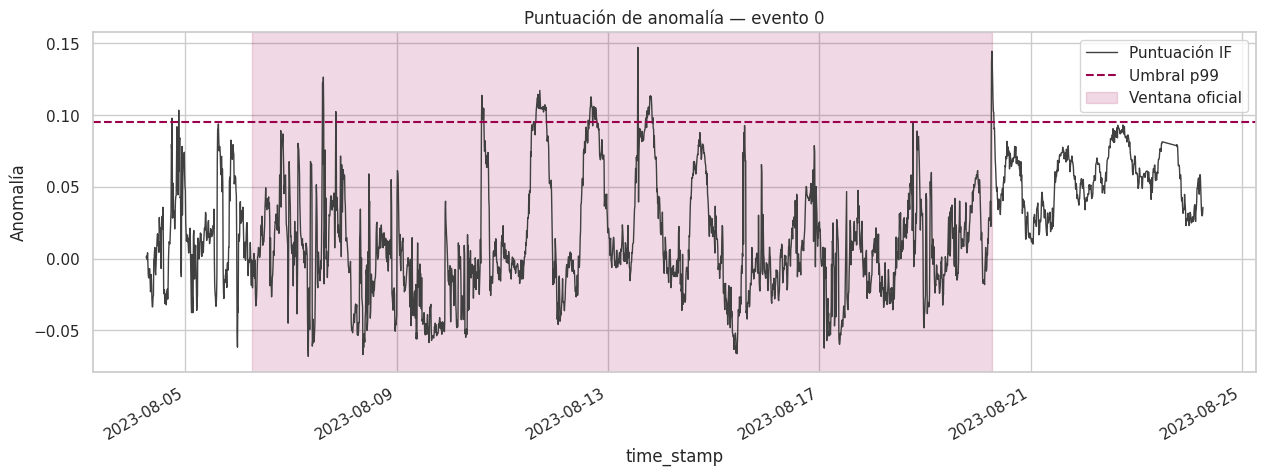

In [7]:
prediction0 = event0.loc[score_mask].set_index("time_stamp")
event_start = pd.to_datetime(meta0["event_start"])
event_end = pd.to_datetime(meta0["event_end"])

fig, ax = plt.subplots(figsize=(15, 5))
prediction0["if_score"].plot(ax=ax, color="#404040", lw=1, label="Puntuación IF")
ax.axhline(threshold_if, color="#9B004C", ls="--", label="Umbral p99")
ax.axvspan(event_start, event_end, color="#9B004C", alpha=0.15, label="Ventana oficial")
ax.set(title="Puntuación de anomalía — evento 0", ylabel="Anomalía")
ax.legend()
plt.show()

### Ejercicio 2 — Sensibilidad del umbral

1. Repite las alertas con los percentiles 0.975, 0.99 y 0.995 del baseline.
2. Compara el número de alertas dentro y fuera de la ventana oficial.
3. Explica el intercambio entre anticipación y falsas alarmas.

## 7. Comparación con Local Outlier Factor

LOF se ajusta en modo `novelty=True` porque el objetivo es puntuar datos futuros. No debe utilizarse `fit_predict` sobre los mismos datos de entrenamiento en este escenario.

In [8]:
lof = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", LocalOutlierFactor(
        n_neighbors=35,
        novelty=True,
        contamination=0.01,
        n_jobs=-1,
    )),
])

lof_sample = X_train.sample(min(12000, len(X_train)), random_state=RANDOM_STATE)
lof.fit(lof_sample)

lof_train_score = -lof.decision_function(X_train)
event0.loc[score_mask, "lof_score"] = -lof.decision_function(X_prediction)
threshold_lof = np.quantile(lof_train_score, 0.99)
event0["lof_alert"] = event0["lof_score"].gt(threshold_lof)

event0.loc[score_mask, ["if_alert", "lof_alert"]].sum()

,0
if_alert,93
lof_alert,305


### Ejercicio 3 — Comparar detectores

Calcula para cada método: alertas dentro de la ventana, alertas fuera de ella y primera alerta. Después indica cuál sería preferible si una inspección falsa fuera costosa.

## 8. Perfiles mensuales para segmentar activos

Cada fila del clustering representará un mes de comportamiento normal de un activo. Después se asignará a cada aerogenerador su clúster dominante.

In [9]:
fleet = pd.concat(frames.values(), ignore_index=True)
fleet = fleet.loc[
    fleet["train_test"].eq("train") & fleet["status_type_id"].isin([0, 2])
].copy()
fleet["month"] = fleet["time_stamp"].dt.to_period("M").dt.to_timestamp()

PROFILE_SIGNALS = [
    "wind_speed_3_avg", "power_30_avg", "sensor_11_avg",
    "sensor_12_avg", "sensor_13_avg", "sensor_14_avg", "sensor_41_avg",
]

monthly_median = fleet.groupby(["asset_id", "month"])[PROFILE_SIGNALS].median()
monthly_iqr = fleet.groupby(["asset_id", "month"])[PROFILE_SIGNALS].agg(
    lambda s: s.quantile(0.75) - s.quantile(0.25)
)
monthly_median.columns = [f"{c}_median" for c in monthly_median.columns]
monthly_iqr.columns = [f"{c}_iqr" for c in monthly_iqr.columns]
profiles = monthly_median.join(monthly_iqr).dropna().reset_index()
profiles.head()

,asset_id,month,wind_speed_3_avg_median,power_30_avg_median,sensor_11_avg_median,sensor_12_avg_median,sensor_13_avg_median,sensor_14_avg_median,sensor_41_avg_median,wind_speed_3_avg_iqr,power_30_avg_iqr,sensor_11_avg_iqr,sensor_12_avg_iqr,sensor_13_avg_iqr,sensor_14_avg_iqr,sensor_41_avg_iqr
0,0,2022-08-01,6.7,0.131341,56.0,52.0,53.0,51.0,46.0,8.7,0.883622,18.0,9.0,34.0,32.0,6.0
1,0,2022-09-01,5.3,0.071049,53.0,50.0,45.0,44.0,48.0,4.8,0.315524,14.0,7.0,18.0,15.0,6.0
2,0,2022-10-01,5.1,0.078146,51.0,48.0,45.0,43.0,36.0,5.2,0.400220,17.0,10.0,24.0,18.0,6.0
3,0,2022-11-01,4.6,0.065976,49.0,46.0,37.0,39.0,31.0,4.0,0.308585,13.0,10.0,16.0,14.0,6.0
4,0,2022-12-01,6.5,0.239171,55.0,51.0,43.0,41.0,31.0,4.7,0.584793,11.0,8.0,17.0,16.0,10.0


### Ejercicio 4 — Validar los perfiles

1. Cuenta los perfiles mensuales por activo.
2. Comprueba que todas las características tengan variación.
3. Explica por qué no se debe incluir `asset_id` como variable numérica del modelo.

## 9. Selección de k, K-Means e interpretación

In [10]:
feature_cols = profiles.columns.difference(["asset_id", "month"])
X_profiles = profiles[feature_cols]

cluster_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
X_scaled = cluster_pipe.fit_transform(X_profiles)

scores = {}
for k in range(2, 6):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

best_k = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=RANDOM_STATE)
profiles["cluster"] = kmeans.fit_predict(X_scaled)

pd.Series(scores, name="silhouette")

,silhouette
2,0.247205
3,0.223778
4,0.209215
5,0.231817


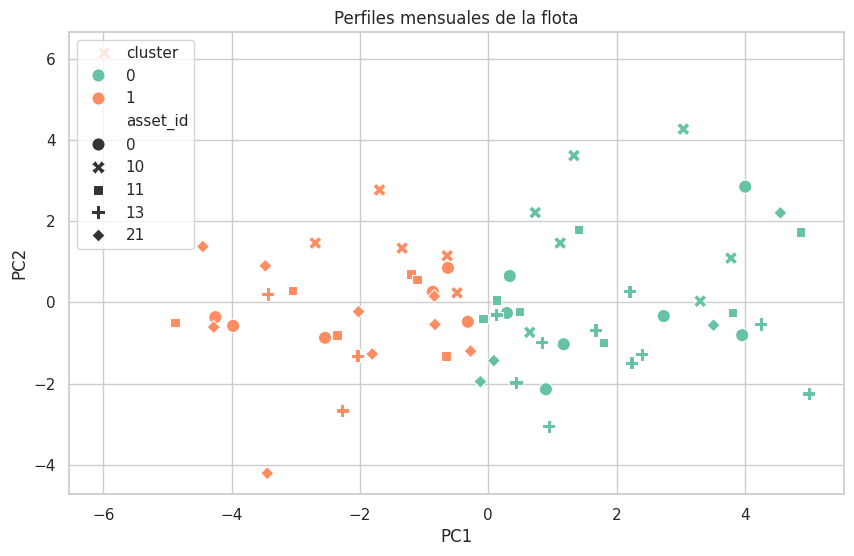

,dominant_cluster
asset_id,
0,0
10,0
11,0
13,0
21,1


In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
profiles["PC1"] = coords[:, 0]
profiles["PC2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=profiles,
    x="PC1", y="PC2",
    hue="cluster", style="asset_id",
    palette="Set2", s=90, ax=ax,
)
ax.set_title("Perfiles mensuales de la flota")
plt.show()

asset_segment = (
    profiles.groupby("asset_id")["cluster"]
    .agg(lambda s: s.value_counts().idxmax())
    .rename("dominant_cluster")
)
asset_segment

### Ejercicio 5 — Interpretar los clústeres

Calcula la mediana de cada característica por clúster, estandariza la tabla para compararla y asigna un nombre técnico a cada perfil. No utilices etiquetas como “bueno” o “malo” sin evidencia física.

## Tarea integradora

1. Propón un detector final para el evento 0 y justifica método, señales, baseline y umbral.
2. Define tres indicadores operativos para evaluar sus alertas.
3. Interpreta la segmentación de activos y propone una acción diferente para cada perfil.
4. Documenta dos riesgos de fuga de información o mala interpretación.

## Referencias

- [Dataset CARE to Compare, versión 6](https://doi.org/10.5281/zenodo.15846963)
- [Artículo CARE to Compare](https://doi.org/10.3390/data9120138)
- [Scikit-learn: Novelty and Outlier Detection](https://scikit-learn.org/stable/modules/outlier_detection.html)
- [Scikit-learn: Clustering](https://scikit-learn.org/stable/modules/clustering.html)